In [2]:
import sqlite3
import sys  

In [3]:
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()

# user_query = "SELECT COUNT(*) FROM review_logs"
user_query = """
SELECT message, COUNT(*) AS weight 
FROM review_logs
GROUP BY message
ORDER BY weight DESC
LIMIT 20
"""

cursor.execute(user_query)

all_rows = cursor.fetchall()

print(f"{'WEIGHT / COUNT':<15} | {'REVIEW MESSAGE'}")
print('-' * 50)
for row in all_rows:
    message = row[0]
    weight = row[1]
    print(f"{weight:<15} | {message}")
    
conn.close()

WEIGHT / COUNT  | REVIEW MESSAGE
--------------------------------------------------
630             | Review text not found
159             | None
3               | Amazon used to be great with product prices and delivery. I waited for products that had a 1 day delivery. They are had two.Ä̳m̳å̳z̳ð̳ñ̳̳¢̳µ̳§̳†̳ð̳m̳ê̳r̳ ̳§̳ê̳r̳v̳ï̳¢̳ê̳ ̳h̳ê̳l̳þ̳l̳ï̳ñ̳ê̳ ̳þ̳h̳ð̳ñ̳ê̳ ̳ñ̳µ̳m̳ß̳ê̳r̳ ̳ï̳§̳ ̳+̳1̳ ̳8̳4̳4̳ ̳4̳2̳0̳ ̳0̳0̳7̳2̳Ä̳m̳å̳z̳ð̳ñ̳̳¢̳µ̳§̳†̳ð̳m̳ê̳r̳ ̳§̳ê̳r̳v̳ï̳¢̳ê̳ ̳h̳ê̳l̳þ̳l̳ï̳ñ̳ê̳ ̳þ̳h̳ð̳ñ̳ê̳ ̳ñ̳µ̳m̳ß̳ê̳r̳ ̳ï̳§̳ ̳+̳1̳ ̳8̳4̳4̳ ̳4̳2̳0̳ ̳0̳0̳7̳2̳Ä̳m̳å̳z̳ð̳ñ̳̳¢̳µ̳§̳†̳ð̳m̳ê̳r̳ ̳§̳ê̳r̳v̳ï̳¢̳ê̳ ̳h̳ê̳l̳þ̳l̳ï̳ñ̳ê̳ ̳þ̳h̳ð̳ñ̳ê̳ ̳ñ̳µ̳m̳ß̳ê̳r̳ ̳ï̳§̳ ̳+̳1̳ ̳8̳4̳4̳ ̳4̳2̳0̳ ̳0̳0̳7̳2̳Ä̳m̳å̳z̳ð̳ñ̳̳¢̳µ̳§̳†̳ð̳m̳ê̳r̳ ̳§̳ê̳r̳v̳ï̳¢̳ê̳ ̳h̳ê̳l̳þ̳l̳ï̳ñ̳ê̳ ̳þ̳h̳ð̳ñ̳ê̳ ̳ñ̳µ̳m̳ß̳ê̳r̳ ̳ï̳§̳ ̳+̳1̳ ̳8̳4̳4̳ ̳4̳2̳0̳ ̳0̳0̳7̳2̳Ä̳m̳å̳z̳ð̳ñ̳̳¢̳µ̳§̳†̳ð̳m̳ê̳r̳ ̳§̳ê̳r̳v̳ï̳¢̳ê̳ ̳h̳ê̳l̳þ̳l̳ï̳ñ̳ê̳ ̳þ̳h̳ð̳ñ̳ê̳ ̳ñ̳µ̳m̳ß̳ê̳r̳ ̳ï̳§̳ ̳+̳1̳ ̳8̳4̳4̳ ̳4̳2̳0̳ ̳0̳0̳7̳2̳Ä̳m̳å̳z̳ð̳ñ̳̳¢̳µ̳§̳†̳ð̳m̳ê̳r̳ ̳§̳ê̳r̳v̳ï̳¢̳ê̳ ̳h̳ê̳l̳þ̳l̳ï̳ñ̳ê̳ ̳þ̳h̳ð̳ñ̳ê̳ 

In [4]:
import sqlite3
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# 1. Fetch clean text from the original log table
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()
cursor.execute("SELECT username, message FROM review_logs")
rows = cursor.fetchall()

dataset = []
for row in rows:
    # Filter out missing strings
    if row[1] and row[1] not in ("Review text not found", "None"):
        dataset.append({"username": row[0], "message": row[1]})

sentences = [item["message"] for item in dataset]
usernames = [item["username"] for item in dataset]

print(f"Loaded {len(sentences)} clean sentences.")

# 2. Compute high-dimensional embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences, show_progress_bar=True)

# 3. Compress vectors to 3D coordinates via PCA
print("Compressing dimensions down to X, Y, Z...")
pca = PCA(n_components=3)
embeddings_3d = pca.fit_transform(embeddings)

# 4. Initialize the new target database table
cursor.execute("DROP TABLE IF EXISTS review_emb")
cursor.execute("""
CREATE TABLE review_emb (
    user_name TEXT,
    x REAL,
    y REAL,
    z REAL,
    review TEXT
)
""")

# 5. Fast batch insert into SQLite
print("Writing 3D coordinates to 'review_emb' table...")
insert_data = []
for i in range(len(dataset)):
    insert_data.append((
        usernames[i],
        float(embeddings_3d[i, 0]),
        float(embeddings_3d[i, 1]),
        float(embeddings_3d[i, 2]),
        sentences[i]
    ))

cursor.executemany(
    "INSERT INTO review_emb (user_name, x, y, z, review) VALUES (?, ?, ?, ?, ?)",
    insert_data
)
conn.commit()
conn.close()

print("Step 1 complete. 3D spatial data successfully locked into database!")

/home/sachinkumar/Desktop/sponser_proof_gen/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 20425 clean sentences.


Batches: 100%|██████████| 639/639 [00:41<00:00, 15.38it/s]


Compressing dimensions down to X, Y, Z...
Writing 3D coordinates to 'review_emb' table...
Step 1 complete. 3D spatial data successfully locked into database!


### Visualizing PCA for better understanding.

In [5]:
import sqlite3
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

print("Extracting a randomized 5,000 row sample from 'review_emb'...")
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()

# ORDER BY RANDOM() shuffles the data rows before picking the top 5000
cursor.execute("""
    SELECT user_name, x, y, z, review 
    FROM review_emb 
    ORDER BY RANDOM() 
    LIMIT 500
""")
rows = cursor.fetchall()
conn.close()

# Unpack columns
usernames = [row[0] for row in rows]
x_coords = [row[1] for row in rows]
y_coords = [row[2] for row in rows]
z_coords = [row[3] for row in rows]
reviews = [row[4] for row in rows]

hover_texts = [msg if len(msg) < 80 else msg[:77] + "..." for msg in reviews]

print(f"Launching browser to render {len(rows)} randomized data points in 3D...")

fig = px.scatter_3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    hover_name=reviews,       
    text=usernames,          
    labels={'x': 'PCA X', 'y': 'PCA Y', 'z': 'PCA Z'},
    title="Randomized 3D Semantic Review Interface (5K Sample)"
)

fig.update_traces(
    marker=dict(
        size=3.0,              
        opacity=0.75,           
        line=dict(width=0)     
    ),
    selector=dict(mode='markers')
)

fig.show()

Extracting a randomized 5,000 row sample from 'review_emb'...
Launching browser to render 500 randomized data points in 3D...


In [8]:
import sqlite3
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

print("Extracting a randomized 5,000 row sample from 'review_emb'...")
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()

# ORDER BY RANDOM() shuffles the data rows before picking the top 500
cursor.execute("""
    SELECT user_name, x, y, z, review 
    FROM review_emb 
    ORDER BY RANDOM() 
    LIMIT 50
""")
rows = cursor.fetchall()
conn.close()

# Unpack columns
usernames = [row[0] for row in rows]
x_coords = [row[1] for row in rows]
y_coords = [row[2] for row in rows]
z_coords = [row[3] for row in rows]
reviews = [row[4] for row in rows]

# --- TEXT WRAPPING LOGIC ---
formatted_reviews = []
for msg in reviews:
    if not msg:
        formatted_reviews.append("")
        continue
        
    words = msg.split()
    lines = []
    current_line = []
    current_length = 0
    
    for word in words:
        current_line.append(word)
        current_length += len(word) + 1
        
        # Insert a break tag once a line reaches roughly 50 characters
        if current_length >= 50:
            lines.append(" ".join(current_line))
            current_line = []
            current_length = 0
            
    if current_line:
        lines.append(" ".join(current_line))
        
    # Join with HTML break tags for Plotly to render vertically
    wrapped_text = "<br>".join(lines)
    formatted_reviews.append(wrapped_text)
# ---------------------------

print(f"Launching browser to render {len(rows)} randomized data points in 3D...")

fig = px.scatter_3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    hover_name=formatted_reviews,       # Changed to usernames (bold title)
    text=usernames,     # Changed to our wrapped multi-line review text
    labels={'x': 'PCA X', 'y': 'PCA Y', 'z': 'PCA Z'},
    title="Randomized 3D Semantic Review Interface (5K Sample)"
)

fig.update_traces(
    marker=dict(
        size=3.0,              
        opacity=0.75,           
        line=dict(width=0)     
    ),
    selector=dict(mode='markers')
)

fig.show()

Extracting a randomized 5,000 row sample from 'review_emb'...
Launching browser to render 50 randomized data points in 3D...


In [9]:
import sqlite3
import plotly.express as px
import plotly.io as pio
from sklearn.cluster import KMeans

pio.renderers.default = 'browser'

print("Extracting sample from 'review_emb'...")
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()

# Grab a random sample of reviews
cursor.execute("""
    SELECT user_name, x, y, z, review 
    FROM review_emb 
    ORDER BY RANDOM() 
    LIMIT 500
""")
rows = cursor.fetchall()
conn.close()

# Unpack columns
usernames = [row[0] for row in rows]
x_coords = [row[1] for row in rows]
y_coords = [row[2] for row in rows]
z_coords = [row[3] for row in rows]
reviews = [row[4] for row in rows]

# --- K-MEANS CLUSTERING LAYER ---
print("Running K-Means clustering...")
# Combine coordinates into a single 2D array for scikit-learn
coordinates = list(zip(x_coords, y_coords, z_coords))

# n_clusters=4 splits the data into 4 distinct colorful groups
# random_state=42 ensures the color groups stay consistent every time you run it
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(coordinates)

# Convert group numbers to string text labels so Plotly treats them as distinct categories
cluster_strings = [f"Cluster {num}" for num in cluster_labels]
# --------------------------------

# --- TEXT WRAPPING LAYER ---
formatted_reviews = []
for msg in reviews:
    if not msg:
        formatted_reviews.append("")
        continue
        
    words = msg.split()
    lines = []
    current_line = []
    current_length = 0
    
    for word in words:
        current_line.append(word)
        current_length += len(word) + 1
        if current_length >= 50:
            lines.append(" ".join(current_line))
            current_line = []
            current_length = 0
            
    if current_line:
        lines.append(" ".join(current_line))
        
    wrapped_text = "<br>".join(lines)
    formatted_reviews.append(wrapped_text)
# ---------------------------

print(f"Launching browser to render clustered data groups...")

fig = px.scatter_3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    color=cluster_strings,      # Color-codes the dots dynamically based on K-Means groups
    hover_name=formatted_reviews,       # Changed to usernames (bold title)
    text=usernames,     
    labels={'x': 'PCA X', 'y': 'PCA Y', 'z': 'PCA Z', 'color': 'Group ID'},
    title="K-Means Clustering on 3D Semantic Space (5K Sample)"
)

fig.update_traces(
    marker=dict(
        size=3.0,              
        opacity=0.85,           
        line=dict(width=0)     
    ),
    selector=dict(mode='markers')
)

fig.show()

Extracting sample from 'review_emb'...
Running K-Means clustering...
Launching browser to render clustered data groups...


Finding Optimal clustering

Extracting coordinates from 'review_emb'...
Evaluating cluster configurations...
Calculated Inertia for K=2: 1753.63
Calculated Inertia for K=3: 1330.17
Calculated Inertia for K=4: 1017.46
Calculated Inertia for K=5: 865.69
Calculated Inertia for K=6: 772.22
Calculated Inertia for K=7: 696.30
Calculated Inertia for K=8: 634.62
Calculated Inertia for K=9: 582.31
Calculated Inertia for K=10: 545.15
Calculated Inertia for K=11: 512.80
Calculated Inertia for K=12: 490.43

Displaying elbow metric chart...


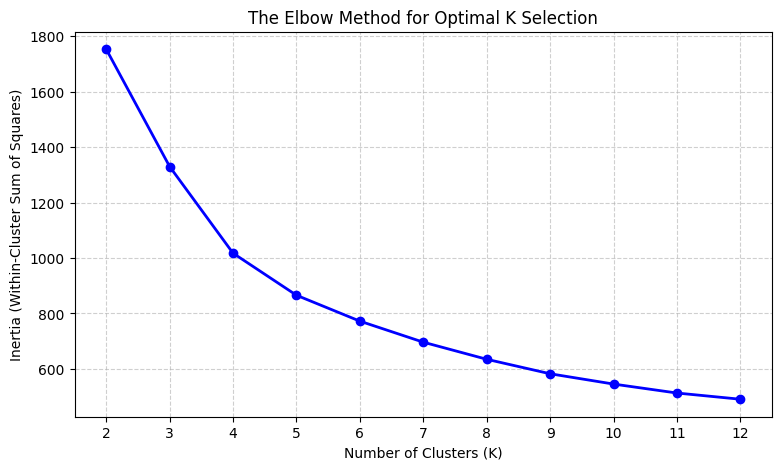

In [10]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Extracting coordinates from 'review_emb'...")
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()
cursor.execute("SELECT x, y, z FROM review_emb")
rows = cursor.fetchall()
conn.close()

# Convert to a standard NumPy matrix
coordinates = np.array(rows)

# Define the range of cluster counts to test
cluster_range = range(2, 13)
inertia_scores = []

print("Evaluating cluster configurations...")
for k in cluster_range:
    # n_init='auto' keeps the optimization processing fast
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(coordinates)
    inertia_scores.append(kmeans.inertia_)
    print(f"Calculated Inertia for K={k}: {kmeans.inertia_:.2f}")

# Plot the Elbow Curve using standard Matplotlib
plt.figure(figsize=(9, 5))
plt.plot(cluster_range, inertia_scores, marker='o', linestyle='-', color='blue', linewidth=2)
plt.title('The Elbow Method for Optimal K Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(cluster_range)
plt.grid(True, linestyle='--', alpha=0.6)

print("\nDisplaying elbow metric chart...")
plt.show()

In [11]:
import sqlite3
import plotly.express as px
import plotly.io as pio

pio.renderers.default = 'browser'

print("Extracting a randomized 5,000 row sample from 'review_emb'...")
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()

# ORDER BY RANDOM() shuffles the data rows before picking the top 5000
cursor.execute("""
    SELECT user_name, x, y, z, review 
    FROM review_emb 
    ORDER BY RANDOM() 
    LIMIT 500
""")
rows = cursor.fetchall()
conn.close()

# Unpack columns
usernames = [row[0] for row in rows]
x_coords = [row[1] for row in rows]
y_coords = [row[2] for row in rows]
z_coords = [row[3] for row in rows]
reviews = [row[4] for row in rows]

hover_texts = [msg if len(msg) < 80 else msg[:77] + "..." for msg in reviews]

print(f"Launching browser to render {len(rows)} randomized data points in 3D...")

fig = px.scatter_3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    hover_name=reviews,       
    text=usernames,          
    labels={'x': 'PCA X', 'y': 'PCA Y', 'z': 'PCA Z'},
    title="Randomized 3D Semantic Review Interface (5K Sample)"
)

fig.update_traces(
    marker=dict(
        size=3.0,              
        opacity=0.75,           
        line=dict(width=0)     
    ),
    selector=dict(mode='markers')
)

fig.show()

Extracting a randomized 5,000 row sample from 'review_emb'...
Launching browser to render 500 randomized data points in 3D...


In [12]:
import sqlite3
import numpy as np
from sklearn.cluster import KMeans

print("Extracting full dataset coordinates from 'review_emb'...")
conn = sqlite3.connect("test_reviews.db")
cursor = conn.cursor()
cursor.execute("SELECT user_name, x, y, z, review FROM review_emb")
rows = cursor.fetchall()
conn.close()

# Unpack columns into numpy arrays for fast vector math
usernames = [row[0] for row in rows]
reviews = [row[4] for row in rows]
coordinates = np.array([[row[1], row[2], row[3]] for row in rows])

# 1. Run K-Means on the entire dataset to match your visualization setup
print("Calculating clusters and centroids...")
num_clusters = 8
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(coordinates)

# Extract the calculated X, Y, Z coordinates for the center of each group
centroids = kmeans.cluster_centers_

print("\n=== CLUSTERING GUT-CHECK: EXEGESIS OF CENTROID EXEMPLARS ===")
print("============================================================")

# 2. Loop through each individual cluster group
for cluster_id in range(num_clusters):
    print(f"\n📁 CLUSTER {cluster_id} EXEMPLARS (Closest to Core Meaning):")
    print("-" * 60)
    
    # Get the 3D coordinate profile of the current cluster's center
    centroid = centroids[cluster_id]
    
    # Isolate the index positions of all reviews belonging to this cluster
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    
    # Extract the actual coordinates for just this cluster's members
    cluster_coords = coordinates[cluster_indices]
    
    # Calculate the Euclidean distance from every member dot to the cluster center
    # Formula: sqrt((x1-x2)^2 + (y1-y2)^2 + (z1-z2)^2)
    distances = np.linalg.norm(cluster_coords - centroid, axis=1)
    
    # Sort the distances and grab the 5 closest indices
    closest_relative_indices = np.argsort(distances)[:5]
    
    # Map back to the absolute indices of our master arrays
    closest_master_indices = cluster_indices[closest_relative_indices]
    
    # 3. Print out the top 5 exemplary reviews
    for rank, idx in enumerate(closest_master_indices, 1):
        user = usernames[idx]
        text = reviews[idx].strip().replace("\n", " ")
        # Truncate text block gracefully for terminal viewing
        display_text = text if len(text) < 120 else text[:117] + "..."
        
        print(f" {rank}. [{user}]: {display_text}")

Extracting full dataset coordinates from 'review_emb'...
Calculating clusters and centroids...

=== CLUSTERING GUT-CHECK: EXEGESIS OF CENTROID EXEMPLARS ===

📁 CLUSTER 0 EXEMPLARS (Closest to Core Meaning):
------------------------------------------------------------
 1. [kate]: Often buy through Amazon and never really have any problem . Have had drivers leave parcel at front door in full view...
 2. [Mr B Duxbury]: i ordered rigid pipe cutter and assume it came from usa, they were delivered 3 days earlier than stated  great service.
 3. [RENO]: I have only had 1 order thats been late and still is, masks from china LOL..Every other order has been bang on time o...
 4. [Danielle Farris]: Amazon delivered my package on the wrong porch! 😤 Now I have to go next door and look like a PACKAGE THIEF!! 🤦🏽‍♀️
 5. [Lorraine Rogers]: Great company quick delivery! Ordered my iPhone cover, says it will come in 3 days but it came the next day!

📁 CLUSTER 1 EXEMPLARS (Closest to Core Meaning):
------

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("Grouping reviews by cluster for text analysis...")

# 1. Combine all reviews in the same cluster into a single mega-document
cluster_documents = []
for cluster_id in range(num_clusters):
    indices = np.where(cluster_labels == cluster_id)[0]
    # Join all reviews belonging to this cluster into one big string
    combined_text = " ".join([reviews[idx] for idx in indices if reviews[idx]])
    cluster_documents.append(combined_text)

# 2. Initialize TF-IDF Vectorizer with standard English stop words removed
# ngram_range=(1, 2) allows it to catch both single words and two-word phrases (like "customer service")
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=10000)
tfidf_matrix = vectorizer.fit_transform(cluster_documents)

# Get the list of actual words/phrases matched by the vectorizer
feature_names = np.array(vectorizer.get_feature_names_out())

print("\n=== CLUSTER TOPIC GENERATION & KEYWORD EXTRACTION ===")
print("======================================================")

# 3. Extract top terms for each cluster
for cluster_id in range(num_clusters):
    # Get the row of TF-IDF scores for the current cluster document
    tfidf_scores = tfidf_matrix[cluster_id].toarray().flatten()
    
    # Sort the scores in descending order and grab the top 10 positions
    top_indices = np.argsort(tfidf_scores)[::-1][:10]
    top_keywords = feature_names[top_indices]
    
    # 4. Generate a Dynamic Topic Heading using the top 3 strongest keywords
    topic_heading = " / ".join([word.upper() for word in top_keywords[:3]])
    
    # Print the final results
    print(f"\n📌 TOPIC: {topic_heading}")
    print(f"📁 Cluster {cluster_id} Core Keywords:")
    print("-" * 54)
    for rank, word in enumerate(top_keywords, 1):
        score = tfidf_scores[vectorizer.vocabulary_[word]]
        print(f"  {rank}. {word:<25} (Weight Score: {score:.3f})")

Grouping reviews by cluster for text analysis...

=== CLUSTER TOPIC GENERATION & KEYWORD EXTRACTION ===

📌 TOPIC: DELIVERY / AMAZON / SERVICE
📁 Cluster 0 Core Keywords:
------------------------------------------------------
  1. delivery                  (Weight Score: 0.482)
  2. amazon                    (Weight Score: 0.349)
  3. service                   (Weight Score: 0.244)
  4. delivered                 (Weight Score: 0.216)
  5. time                      (Weight Score: 0.199)
  6. order                     (Weight Score: 0.190)
  7. customer                  (Weight Score: 0.185)
  8. package                   (Weight Score: 0.166)
  9. ordered                   (Weight Score: 0.165)
  10. day                       (Weight Score: 0.155)

📌 TOPIC: AMAZON / ACCOUNT / CUSTOMER
📁 Cluster 1 Core Keywords:
------------------------------------------------------
  1. amazon                    (Weight Score: 0.665)
  2. account                   (Weight Score: 0.298)
  3. customer      

The Optimized Keyword Code

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

print("Grouping reviews by cluster for advanced text analysis...")

cluster_documents = []
for cluster_id in range(num_clusters):
    indices = np.where(cluster_labels == cluster_id)[0]
    combined_text = " ".join([reviews[idx] for idx in indices if reviews[idx]])
    cluster_documents.append(combined_text)

# --- ADVANCED TUNING LAYER ---
# max_df=0.60: Automatically drops any word that appears in more than 60% of the clusters (destroys "amazon", "customer", "service")
# sublinear_tf=True: Attenuates heavy repetition frequency bursts
vectorizer = TfidfVectorizer(
    stop_words='english', 
    ngram_range=(1, 2), 
    max_df=0.60, 
    sublinear_tf=True,
    max_features=10000
)
# ------------------------------

tfidf_matrix = vectorizer.fit_transform(cluster_documents)
feature_names = np.array(vectorizer.get_feature_names_out())

print("\n=== TUNED CLUSTER TOPIC GENERATION & KEYWORD EXTRACTION ===")
print("============================================================")

for cluster_id in range(num_clusters):
    tfidf_scores = tfidf_matrix[cluster_id].toarray().flatten()
    
    # Catch empty edge cases safely
    if np.all(tfidf_scores == 0):
        print(f"\n📌 TOPIC: EMPTY CLUSTER {cluster_id}")
        continue
        
    top_indices = np.argsort(tfidf_scores)[::-1][:10]
    top_keywords = feature_names[top_indices]
    
    # Dynamic Topic Heading via clean, hyper-focused vocabulary tokens
    topic_heading = " / ".join([word.upper() for word in top_keywords[:3]])
    
    print(f"\n📌 TOPIC: {topic_heading}")
    print(f"📁 Cluster {cluster_id} Core Keywords:")
    print("-" * 54)
    for rank, word in enumerate(top_keywords, 1):
        score = tfidf_scores[vectorizer.vocabulary_[word]]
        print(f"  {rank}. {word:<25} (Weight Score: {score:.3f})")

Grouping reviews by cluster for advanced text analysis...

=== TUNED CLUSTER TOPIC GENERATION & KEYWORD EXTRACTION ===

📌 TOPIC: BED BED / AMNICS CUSTOMER / AMNICS
📁 Cluster 0 Core Keywords:
------------------------------------------------------
  1. bed bed                   (Weight Score: 0.106)
  2. amnics customer           (Weight Score: 0.055)
  3. amnics                    (Weight Score: 0.055)
  4. porch door                (Weight Score: 0.052)
  5. raining                   (Weight Score: 0.049)
  6. knocking                  (Weight Score: 0.049)
  7. packages left             (Weight Score: 0.048)
  8. knocking door             (Weight Score: 0.047)
  9. ring door                 (Weight Score: 0.046)
  10. leave packages            (Weight Score: 0.046)

📌 TOPIC: ACCOUNT SPECIALIST / BLOCKED ACCOUNT / CHANGED PASSWORD
📁 Cluster 1 Core Keywords:
------------------------------------------------------
  1. account specialist        (Weight Score: 0.033)
  2. blocked account  